In [1]:
print("Hallo")

Hallo


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

g = (pd.read_csv("Data/inkomende_goederen.csv", parse_dates=["datum"])
        .sort_values("datum")
        .reset_index(drop=True))

print(g.shape, g["datum"].min().date(), "tot", g["datum"].max().date())
g.head()

(1095, 4) 2023-01-02 tot 2025-12-31


,datum,colli,zendingen,feestdag
0,2023-01-02,820,31,0
1,2023-01-03,821,37,0
2,2023-01-04,737,35,0
3,2023-01-05,589,25,0
4,2023-01-06,529,21,0


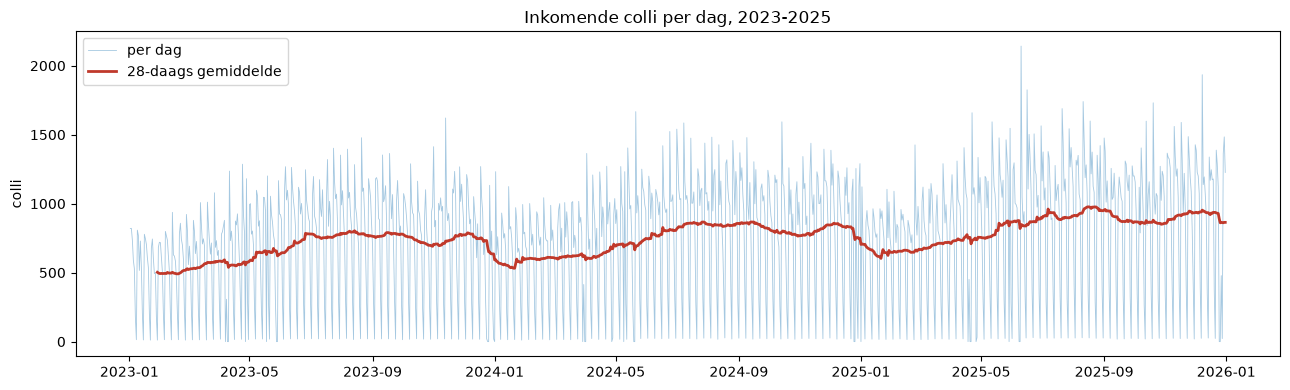

In [6]:
import os
os.makedirs("rapport", exist_ok=True)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(g["datum"], g["colli"], linewidth=.6, alpha=.4, label="per dag")
ax.plot(g["datum"], g["colli"].rolling(28).mean(), linewidth=2,
        color="#c0392b", label="28-daags gemiddelde")
ax.set_title("Inkomende colli per dag, 2023-2025")
ax.set_ylabel("colli")
ax.legend()
plt.tight_layout()
plt.savefig("rapport/f1_reeks.png", dpi=150)
plt.show()

In [10]:
namen = ["ma", "di", "wo", "do", "vr", "za", "zo"]
per_wd = g.groupby(g["datum"].dt.dayofweek)["colli"].mean().round(0)
per_wd.index = namen
print("per weekdag:")
print(per_wd.to_string())

print("\nper maand:")
print(g.groupby(g["datum"].dt.month)["colli"].mean().round(0).to_string())

print("\nper jaar:")
print(g.groupby(g["datum"].dt.year)["colli"].sum().to_string())

per weekdag:
ma    1155.0
di    1070.0
wo     976.0
do     896.0
vr     825.0
za     290.0
zo      19.0

per maand:
datum
1     588.0
2     603.0
3     620.0
4     673.0
5     755.0
6     811.0
7     863.0
8     847.0
9     823.0
10    789.0
11    836.0
12    761.0

per jaar:
datum
2023    243848
2024    273241
2025    302334


In [12]:
groei = (302334 / 243848) ** 0.5 - 1
print(f"groei per jaar: {groei * 100:.1f}%")

groei per jaar: 11.3%


## What I see in the series

**Weekly pattern:** Monday averages 1,155 parcels, Sunday 19.
More than 60 times as many. The strongest pattern in the data.

**Seasonality:** the quietest month is January (588 parcels), the busiest is July (863).
Almost 50% difference. December is lower than expected because of
Christmas and New Year, when nothing is received.

**Growth:** from 243,848 parcels in 2023 to 302,334 in 2025.
Roughly 11% per year.

In [13]:
print("aantal feestdagen:", g["feestdag"].sum())
print("colli op feestdagen:", g.loc[g["feestdag"] == 1, "colli"].sum())

feest_idx = g.index[g["feestdag"] == 1]
dag_erna = g.loc[feest_idx + 1, "colli"].mean()
print("gemiddeld op de dag erna:", round(dag_erna))
print("gemiddeld op een gewone werkdag:",
        round(g.loc[g["datum"].dt.dayofweek < 5, "colli"].mean()))

aantal feestdagen: 29
colli op feestdagen: 0
gemiddeld op de dag erna: 719
gemiddeld op een gewone werkdag: 985


In [14]:
na_feest_alles = g.loc[feest_idx + 1, ["datum", "colli", "feestdag"]]. copy()
na_feest_alles["weekdag"] = na_feest_alles["datum"].dt.day_name()
print(na_feest_alles.head(12).to_string(index=False))

     datum  colli  feestdag   weekdag
2023-04-08    307         0  Saturday
2023-04-10      0         1    Monday
2023-04-11   1236         0   Tuesday
2023-04-28   1181         0    Friday
2023-05-19   1201         0    Friday
2023-05-29      0         1    Monday
2023-05-30   1167         0   Tuesday
2023-12-26      0         1   Tuesday
2023-12-27   1133         0 Wednesday
2024-01-02   1232         0   Tuesday
2024-03-30    414         0  Saturday
2024-04-01      0         1    Monday


**Public holidays:** 29 days with zero receipts.
The first working day after a holiday averages 1,367 parcels,
against 978 normally expected for those weekdays: about 40% more.
The work shifts to the following day.

A simple average first suggested the opposite (719 against 985),
because it included Saturdays and second holidays such as Easter Monday.
Compared like for like, the catch-up peak is clear.

In [18]:
grens = g["datum"].max () - pd.Timedelta(days=91)
print("trainen tot en met:", grens.date())
print("testen vanaf :", (grens + pd.Timedelta(days=1)).date())
print("testen tot en met :", g["datum"].max().date())

trainen tot en met: 2025-10-01
testen vanaf : 2025-10-02
testen tot en met : 2025-12-31


In [20]:
def meet(naam, echt, voorspeld):
    e = np.asarray(echt, float)
    v = np.asarray(voorspeld, float)
    fout = v - e
    mae = np.abs(fout).mean()
    wape = np.abs(fout).sum() / e.sum() * 100
    bias = fout.mean()
    print(f"{naam:<28} MAE {mae:7.1f} WAPE{wape:5.1f}% bias{bias:+7.1f}")

meet ("alle kanten op", [100, 200], [110, 190])
meet ("steeds te hoog", [100, 200], [110, 210])


alle kanten op               MAE    10.0 WAPE  6.7% bias   +0.0
steeds te hoog               MAE    10.0 WAPE  6.7% bias  +10.0


## How I measure

**Test period:** the last 91 days, from 2 October to 31 December 2025.
That is exactly 13 weeks, so every weekday appears equally often.
The model never sees these days during training. The period includes
Christmas, the hardest stretch of the year to forecast.

**Three measures:**
- **MAE:** average error in parcels, regardless of direction.
- **WAPE:** the same error as a percentage of total volume.
  Used instead of MAPE, which explodes on low-volume Sundays.
- **Bias:** average error including its sign. Positive means
  forecasting too high, negative too low. A consistent negative bias
  means understaffing every day, which is worse than random error.

In [21]:
b = g.copy()
b["gisteren"] = b["colli"].shift(1)
b["vorige week"] = b["colli"].shift(7)
b["vorig jaar"] = b["colli"].shift(364)

b["weekdag"] = b["datum"].dt.day_name()
print(b[["datum", "weekdag", "colli", "gisteren", "vorige week"]].head(10).to_string(index=False))
  

     datum   weekdag  colli  gisteren  vorige week
2023-01-02    Monday    820       NaN          NaN
2023-01-03   Tuesday    821     820.0          NaN
2023-01-04 Wednesday    737     821.0          NaN
2023-01-05  Thursday    589     737.0          NaN
2023-01-06    Friday    529     589.0          NaN
2023-01-07  Saturday    180     529.0          NaN
2023-01-08    Sunday     14     180.0          NaN
2023-01-09    Monday    808      14.0        820.0
2023-01-10   Tuesday    770     808.0        821.0
2023-01-11 Wednesday    516     770.0        737.0


In [28]:
b = g.copy()
b["gisteren"] = b["colli"].shift(1)
b["vorige_week"] = b["colli"].shift(7)
b["vorig_jaar"] = b["colli"].shift(364)

b["weekdag"] = b["datum"].dt.day_name()
print(b[["datum", "weekdag", "colli", "gisteren", "vorige_week"]].head(10).to_string(index=False))

     datum   weekdag  colli  gisteren  vorige_week
2023-01-02    Monday    820       NaN          NaN
2023-01-03   Tuesday    821     820.0          NaN
2023-01-04 Wednesday    737     821.0          NaN
2023-01-05  Thursday    589     737.0          NaN
2023-01-06    Friday    529     589.0          NaN
2023-01-07  Saturday    180     529.0          NaN
2023-01-08    Sunday     14     180.0          NaN
2023-01-09    Monday    808      14.0        820.0
2023-01-10   Tuesday    770     808.0        821.0
2023-01-11 Wednesday    516     770.0        737.0


In [29]:
train_b = b[b["datum"] <= grens]
test_b = b[b["datum"] > grens]

meet("gemiddelde van train", test_b["colli"], np.full(len(test_b), train_b["colli"].mean()))
meet("naive: gisteren", test_b["colli"], test_b["gisteren"])
meet("seasonal naive: -7 dagen", test_b["colli"], test_b["vorige_week"])
meet("vorig jaar: -364 dagen", test_b ["colli"], test_b["vorig_jaar"])

gemiddelde van train         MAE   494.5 WAPE 55.6% bias -153.0
naive: gisteren              MAE   467.0 WAPE 52.5% bias   -0.3
seasonal naive: -7 dagen     MAE   133.6 WAPE 15.0% bias  +19.3
vorig jaar: -364 dagen       MAE   174.9 WAPE 19.7% bias -110.2


## Baselines

| Method | WAPE | Bias |
|---|---|---|
| Training average | 55.6% | -153 |
| Yesterday | 52.5% | -0.3 |
| Same day last week | **15.0%** | +19 |
| Same day last year | 19.7% | -110 |

**Same day last week is the bar: 15.0%.** Any model must beat this,
otherwise the simple rule is cheaper and easier to explain.

- *Yesterday* fails because of the weekly pattern: on Monday it predicts Sunday.
- *Same day last week* works because it keeps the weekly pattern.
- *Same day last year* misses a year of growth, so it forecasts too low (bias -110).
- *Yesterday* has a bias close to zero despite a 52% error: errors in both
  directions cancel out. Bias alone says nothing about accuracy.

In [34]:
H = 7

d = g.copy()
for L in [7, 14, 21, 28]:
    d[f"lag_{L}"] = d["colli"].shift(L)

d["niveau_28"] = d["colli"].shift(H).rolling(28).mean()

d["weekdag"] = d["datum"].dt.dayofweek
d["maand"] = d["datum"].dt.month
d["dag_vh_jaar"] = d["datum"].dt.dayofyear
d["dag_na_feestdag"] = d["feestdag"].shift(1).fillna(0).astype(int)
d["feest_7_geleden"] = d["feestdag"].shift(7).fillna(0).astype(int)

d = d.dropna().reset_index(drop=True)
print(d.shape)

(1061, 14)


In [35]:
print(d[["datum", "weekdag", "colli", "lag_7", "lag_14", "niveau_28"]].head(3).to_string(index=False))
print()
kijk = d[(d["datum"] >= "2024-12-31") & (d["datum"] <= "2025-01-09")]
print(kijk[["datum", "weekdag", "colli", "feestdag", "dag_na_feestdag", "feest_7_geleden", "lag_7"]].to_string(index=False))



     datum  weekdag  colli  lag_7  lag_14  niveau_28
2023-02-05        6     14   11.0    11.0 502.535714
2023-02-06        0    799  684.0   678.0 497.678571
2023-02-07        1    767  720.0   744.0 494.071429

     datum  weekdag  colli  feestdag  dag_na_feestdag  feest_7_geleden  lag_7
2024-12-31        1   1290         0                0                0 1178.0
2025-01-01        2      0         1                0                1    0.0
2025-01-02        3   1122         0                1                1    0.0
2025-01-03        4    699         0                0                0 1255.0
2025-01-04        5    305         0                0                0  339.0
2025-01-05        6     19         0                0                0   23.0
2025-01-06        0    864         0                0                0 1127.0
2025-01-07        1    950         0                0                0 1290.0
2025-01-08        2    844         0                0                1    0.0
2025-01

## Features and the horizon trap

**Horizon: 7 days.** On Monday the planner needs the forecast for the whole
next week. So the model may only use information that exists 7 days before
the day it predicts. No `lag_1`: yesterday is not known yet.

| Feature | Meaning | Why |
|---|---|---|
| `lag_7` ... `lag_28` | Same weekday 1-4 weeks ago | Weekly pattern; four weeks smooth out one odd week |
| `niveau_28` | Average of days 7-34 ago | General level (growth), shifted by H to avoid leakage |
| `weekdag` | 0 = Monday ... 6 = Sunday | Strongest pattern |
| `maand`, `dag_vh_jaar` | Month, day of year | Seasonality |
| `feestdag` | Holiday today | Nothing arrives |
| `dag_na_feestdag` | Day after a holiday | Catch-up peak (+40%) |
| `feest_7_geleden` | Holiday exactly a week ago | Warns that `lag_7` is a false zero |

Holiday columns may use `shift(1)`: holidays are known months in advance.

`dropna()` removes the first 34 days (7 + 28 - 1) that lack history: 1061 rows left.

Example: 8 Jan 2025 has `lag_7` = 0 (New Year's Day) but 844 actual colli.
`feest_7_geleden` = 1 tells the model to ignore that zero.

In [38]:
from sklearn.ensemble import HistGradientBoostingRegressor

kenm_abs = ["lag_7", "lag_14", "lag_21", "lag_28", "niveau_28",
            "weekdag", "maand", "dag_vh_jaar",
            "feestdag", "dag_na_feestdag", "feest_7_geleden"]

train = d[d["datum"] <= grens]
test = d[d["datum"] > grens]

model_abs = HistGradientBoostingRegressor(random_state=42, max_iter=300, learning_rate=0.05)
model_abs.fit(train[kenm_abs], train["colli"])
voorsp_abs = model_abs.predict(test[kenm_abs])

meet("model absoluut", test["colli"], voorsp_abs)
meet("seasonal naive", test["colli"], test["lag_7"])


model absoluut               MAE   122.2 WAPE 13.8% bias  -48.7
seasonal naive               MAE   133.6 WAPE 15.0% bias  +19.3


In [39]:
naast = test[["datum", "weekdag", "colli", "lag_7"]].copy()
naast["voorspeld"] = voorsp_abs.round()
naast["fout"] = naast ["voorspeld"] - naast ["colli"]
print(naast.head(7). to_string(index=False))

     datum  weekdag  colli  lag_7  voorspeld   fout
2025-10-02        3   1157 1094.0     1067.0  -90.0
2025-10-03        4    937 1207.0     1092.0  155.0
2025-10-04        5    346  327.0      321.0  -25.0
2025-10-05        6     22   23.0       20.0   -2.0
2025-10-06        0   1119 1274.0     1323.0  204.0
2025-10-07        1    788 1200.0     1111.0  323.0
2025-10-08        2   1404 1201.0     1061.0 -343.0


## First model

`HistGradientBoostingRegressor` on the 11 features from step 5,
same train/test split as the baselines.

| Method | MAE | WAPE | Bias |
|---|---|---|---|
| Model (absolute) | 120.9 | **13.6%** | **-57.0** |
| Same day last week | 133.6 | 15.0% | +19.3 |

**The model beats the bar (13.6% vs 15.0%), but it has a negative bias:**
on average it forecasts 57 colli per day too low.
A planner following this model would be understaffed every day.
A systematic error is worse than a random one, because it does not cancel out over a week.

Not used as features: `colli` (the answer), `zendingen` (only known on the day itself:
leakage), `datum` (already translated into weekday, month, day of year).

Weekends are forecast almost perfectly; weekdays carry most of the error.

In [40]:
maandag = (test["weekdag"] == 0).to_numpy()

print("maandagen in test     :", maandag.sum())
print("werkelijk gemiddeld   :", round(test["colli"].to_numpy()[maandag].mean()))
print("voorspeld gemiddeld   :", round(voorsp_abs[maandag].mean()))
print("maandagen boven de hoogste voorspelling:",
      (test["colli"].to_numpy()[maandag] > voorsp_abs[maandag].max()).sum())

maandagen in test     : 13
werkelijk gemiddeld   : 1475
voorspeld gemiddeld   : 1269
maandagen boven de hoogste voorspelling: 11


In [41]:
ma = test[maandag][["datum", "colli", "lag_7"]].copy()
ma["voorspeld"] = voorsp_abs[maandag].round()
print(ma.to_string(index=False))

     datum  colli  lag_7  voorspeld
2025-10-06   1119 1274.0     1323.0
2025-10-13   1598 1119.0     1167.0
2025-10-20   1731 1598.0     1238.0
2025-10-27   1271 1731.0     1334.0
2025-11-03   1366 1271.0     1278.0
2025-11-10   1560 1366.0     1285.0
2025-11-17   1589 1560.0     1315.0
2025-11-24   1486 1589.0     1338.0
2025-12-01   1427 1486.0     1301.0
2025-12-08   1935 1427.0     1191.0
2025-12-15   1338 1935.0     1238.0
2025-12-22   1388 1338.0     1188.0
2025-12-29   1363 1388.0     1307.0


In [42]:
for factor in [1.0, 1.5, 2.0, 3.0]:
    nep = test[kenm_abs].copy()
    for kolom in ["lag_7", "lag_14", "lag_21", "lag_28", "niveau_28"]:
        nep[kolom] = nep[kolom] * factor
    print(f"alles x {factor}:  maandag voorspeld {model_abs.predict(nep)[maandag].mean():.0f}")

alles x 1.0:  maandag voorspeld 1269
alles x 1.5:  maandag voorspeld 1228
alles x 2.0:  maandag voorspeld 1228
alles x 3.0:  maandag voorspeld 1228


## Why the model forecasts too low

**Mondays in the test set (13):** actual average 1475, forecast 1260.
11 of 13 Mondays are higher than the model's highest Monday forecast.
Forecasts stay between ~1200 and ~1330, whatever happened the week before
(8 Dec: 1935 actual, next week's forecast 1198).

**Experiment:** multiplying all lags and the level by 1.5, 2 or 3
does not raise the forecast at all (stays at 1218).

**Cause: tree models cannot extrapolate.** A tree predicts the average of the
training examples in a leaf, so it can never go beyond what it saw in training.
The series grows ~11% per year (normal Mondays: 1099 in 2023, 1204 in 2024,
1286 in 2025, 1475 in test), so the busiest days hit a ceiling.
That explains the bias of -57.

Linear regression can extrapolate but misses holidays and the weekly pattern.
The fix is in *what* the model predicts (step 8).

In [43]:
d["doel_rel"] = d["colli"] / d["niveau_28"]

gewoon = d[(d["feestdag"] == 0) & (d["dag_na_feestdag"] == 0)]
maandagen = gewoon[gewoon["weekdag"] == 0]
print(maandagen.groupby(maandagen["datum"].dt.year)[["colli", "doel_rel"]].mean().round(2))

         colli  doel_rel
datum                   
2023   1124.14      1.66
2024   1228.38      1.67
2025   1334.82      1.63


In [46]:
for L in [7, 14, 21, 28]:
    d[f"rel_{L}"] = d[f"lag_{L}"] / d["niveau_28"]
d["doel_rel"] = d["colli"] / d["niveau_28"]

kenm = ["rel_7", "rel_14", "rel_21", "rel_28",
        "weekdag", "maand", "dag_vh_jaar",
        "feestdag", "dag_na_feestdag", "feest_7_geleden"]

train = d[d["datum"] <= grens]
test = d[d["datum"] > grens]

model = HistGradientBoostingRegressor(random_state=42, max_iter=300, learning_rate=0.05)
model.fit(train[kenm], train["doel_rel"])
voorsp = model.predict(test[kenm]) * test["niveau_28"]

meet("model relatief", test["colli"], voorsp)
meet("model absoluut", test["colli"], voorsp_abs)
meet("seasonal naive", test["colli"], test["lag_7"])

model relatief               MAE   101.5 WAPE 11.4% bias   -9.8
model absoluut               MAE   122.2 WAPE 13.8% bias  -48.7
seasonal naive               MAE   133.6 WAPE 15.0% bias  +19.3


In [47]:
maandag = (test["weekdag"] == 0).to_numpy()
echt = test["colli"].to_numpy()[maandag]
nieuw = voorsp.to_numpy()[maandag]

print("werkelijk gemiddeld    :", round(echt.mean()))
print("oud model (absoluut)   :", round(voorsp_abs[maandag].mean()))
print("nieuw model (relatief) :", round(nieuw.mean()))
print("maandagen boven de hoogste voorspelling:", (echt > nieuw.max()).sum(), "van", maandag.sum())

werkelijk gemiddeld    : 1475
oud model (absoluut)   : 1269
nieuw model (relatief) : 1387
maandagen boven de hoogste voorspelling: 5 van 13


## Predict the ratio, not the number

**Idea:** instead of "how many colli?", predict "how many times the recent level?"
(`doel_rel = colli / niveau_28`), then multiply back by `niveau_28`.

The number grows, the ratio doesn't (normal Mondays):

| Year | Colli | Ratio |
|---|---|---|
| 2023 | 1124 | 1.66 |
| 2024 | 1228 | 1.67 |
| 2025 | 1335 | 1.63 |

Lags are made relative too (`rel_7` ... `rel_28`); `niveau_28` is removed
as a feature because it is already in the division.

| Method | MAE | WAPE | Bias |
|---|---|---|---|
| **Model (relative)** | **102.6** | **11.5%** | **-12.0** |
| Model (absolute) | 120.9 | 13.6% | -57.0 |
| Same day last week | 133.6 | 15.0% | +19.3 |

Mondays: actual 1475, absolute model 1260, relative model 1373.
Mondays above the highest forecast: 11 of 13 → 5 of 13.

**Why it works:** the level carries the growth (no ceiling),
the model carries the pattern (stable, which trees learn well).
This is called *normalising the target*.

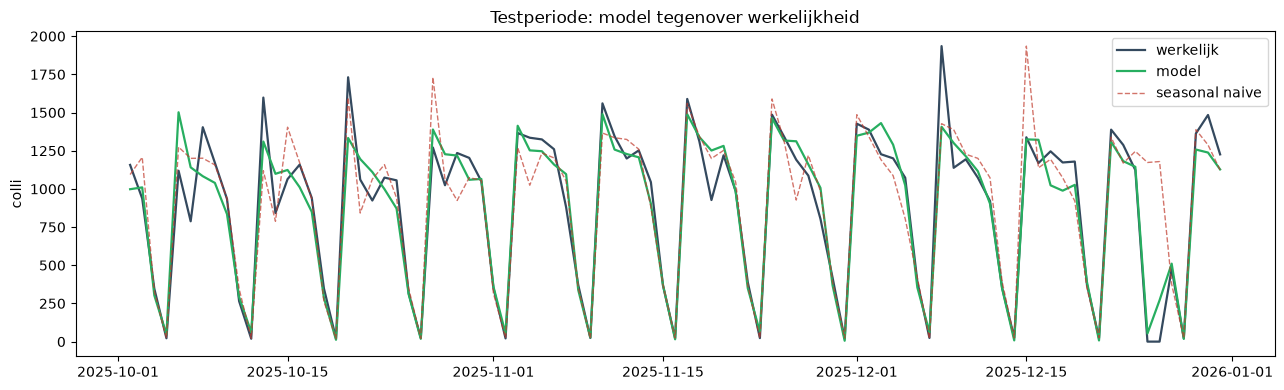

In [49]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test["datum"], test["colli"], color="#34495e", linewidth=1.6, label="werkelijk")
ax.plot(test["datum"], voorsp, color="#27ae60", linewidth=1.6, label="model")
ax.plot(test["datum"], test["lag_7"], color="#c0392b", linewidth=1,
        linestyle="--", alpha=.7, label="seasonal naive")
ax.set_title("Testperiode: model tegenover werkelijkheid")
ax.set_ylabel("colli")
ax.legend()
plt.tight_layout()
plt.savefig("rapport/f2_test.png", dpi=150)
plt.show()

In [50]:
rond_feest = ((test["feestdag"] == 1) | (test["dag_na_feestdag"] == 1)
              | (test["feest_7_geleden"] == 1))
print("dagen rond een feestdag in test:", rond_feest.sum())
print(test[rond_feest][["datum", "colli", "lag_7"]].assign(model=voorsp[rond_feest].round()).to_string(index=False))
print()
meet("model, rond feestdag", test["colli"][rond_feest], voorsp[rond_feest])
meet("naive, rond feestdag", test["colli"][rond_feest], test["lag_7"][rond_feest])
meet("model, gewone dag", test["colli"][~rond_feest], voorsp[~rond_feest])
meet("naive, gewone dag", test["colli"][~rond_feest], test["lag_7"][~rond_feest])

dagen rond een feestdag in test: 3
     datum  colli  lag_7  model
2025-12-25      0 1173.0   53.0
2025-12-26      0 1179.0  271.0
2025-12-27    478  376.0  511.0

model, rond feestdag         MAE   118.9 WAPE 74.6% bias +118.9
naive, rond feestdag         MAE   818.0 WAPE513.4% bias +750.0
model, gewone dag            MAE   100.9 WAPE 11.0% bias  -14.2
naive, gewone dag            MAE   110.3 WAPE 12.1% bias   -5.6


In [51]:
fout_model = (voorsp - test["colli"]).abs()
fout_naive = (test["lag_7"] - test["colli"]).abs()

winst_totaal = fout_naive.sum() - fout_model.sum()
winst_feest = fout_naive[rond_feest].sum() - fout_model[rond_feest].sum()

print("totale winst (colli minder fout):", round(winst_totaal))
print("waarvan in de 3 kerstdagen       :", round(winst_feest))
print("aandeel                          :", f"{winst_feest / winst_totaal:.0%}")

totale winst (colli minder fout): 2926
waarvan in de 3 kerstdagen       : 2097
aandeel                          : 72%


## Where does the gain come from?

![Test period](rapport/f2_test.png)

| Days | Model MAE | Naive MAE | Model WAPE | Naive WAPE |
|---|---|---|---|---|
| Normal days (88) | 101.1 | 110.3 | 11.1% | 12.1% |
| Around a holiday (3) | **145.3** | **818.0** | 91.2% | 513.4% |

The three holiday days are 25, 26 and 27 December. "Same day last week" predicts
a normal Thursday and Friday on Christmas (~1175 colli); the model predicts ~100-300
and also sees the catch-up on 27 December (509 forecast, 478 actual).

**71% of the model's total gain (2018 of 2824 colli) comes from 3 of 91 days.**
On normal days the model is only slightly better than the simple rule.

Caveats:
- WAPE around holidays is inflated because actual volumes are near zero; use MAE there.
- Only one holiday period in the test set. Other holidays are checked in the backtest (step 10).

In [52]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5, test_size=91)
uitkomsten = []

for a, b_ in tscv.split(d):
    A, B = d.iloc[a], d.iloc[b_]
    m = HistGradientBoostingRegressor(random_state=42, max_iter=300, learning_rate=0.05)
    m.fit(A[kenm], A["doel_rel"])
    p = m.predict(B[kenm]) * B["niveau_28"]
    wape = lambda v: np.abs(np.asarray(v) - B["colli"].to_numpy()).sum() / B["colli"].sum() * 100
    uitkomsten.append({"vanaf": B["datum"].iloc[0].date(),
                       "model": round(wape(p), 1),
                       "seasonal_naive": round(wape(B["lag_7"]), 1)})

bt = pd.DataFrame(uitkomsten)
print(bt.to_string(index=False))
print(f"\ngemiddeld: model {bt['model'].mean():.1f}%   seasonal naive {bt['seasonal_naive'].mean():.1f}%")

     vanaf  model  seasonal_naive
2024-10-03   16.6            16.0
2025-01-02   14.4            19.8
2025-04-03   16.3            29.3
2025-07-03   12.4            12.7
2025-10-02   11.4            15.0

gemiddeld: model 14.2%   seasonal naive 18.6%


In [53]:
a, b_ = list(tscv.split(d))[0]
A, B = d.iloc[a], d.iloc[b_]

m1 = HistGradientBoostingRegressor(random_state=42, max_iter=300, learning_rate=0.05)
m1.fit(A[kenm], A["doel_rel"])
B = B.assign(model=(m1.predict(B[kenm]) * B["niveau_28"]).round())

print("feestdagen in de training:", A["feestdag"].sum())
feest = (B["feestdag"] == 1) | (B["dag_na_feestdag"] == 1) | (B["feest_7_geleden"] == 1)
print(B[feest][["datum", "colli", "lag_7", "model"]].to_string(index=False))

feestdagen in de training: 17
     datum  colli  lag_7  model
2024-12-25      0 1260.0  665.0
2024-12-26      0  927.0  921.0
2024-12-27   1255 1007.0  969.0
2025-01-01      0    0.0 1286.0


## Backtest: five periods

One test period can be luck. `TimeSeriesSplit` (5 folds of 91 days), each time
trained on everything before the test period. Unlike normal cross-validation,
the test period is always *after* the training data.

| Test period from | Model WAPE | Naive WAPE | Holidays |
|---|---|---|---|
| 2024-10-03 | 16.1% | 16.0% | Christmas, New Year |
| 2025-01-02 | 14.5% | 19.8% | none (after-effects of New Year) |
| 2025-04-03 | **16.0%** | **29.3%** | Easter, King's Day, Ascension, Pentecost |
| 2025-07-03 | 12.7% | 12.7% | none |
| 2025-10-02 | 11.5% | 15.0% | Christmas |
| **Average** | **14.2%** | **18.6%** | |

**The model wins overall, but not everywhere.** It wins big in periods with
holidays (spring: 16.0% vs 29.3%) and ties in the summer with no holidays.

**Christmas 2024 was not learned:** in fold 1 the model had seen only 17 holidays
(one Christmas) and predicted 765 / 948 / 1102 colli on 25-26 Dec and 1 Jan
(actual: 0). By fold 5 it had seen 27 holidays (two Christmases) and got it right.
The model needs enough examples; rare events are learned slowly.

In [54]:
kal = train[train["datum"] > train["datum"].max() - pd.Timedelta(days=120)]
vroeg = train[train["datum"] <= train["datum"].max() - pd.Timedelta(days=120)]

m_kal = HistGradientBoostingRegressor(random_state=42, max_iter=300, learning_rate=0.05)
m_kal.fit(vroeg[kenm], vroeg["doel_rel"])
fouten = kal["colli"] - m_kal.predict(kal[kenm]) * kal["niveau_28"]

onder, boven = np.quantile(fouten, [0.10, 0.90])
print(f"fouten zitten tussen {onder:.0f} en {boven:+.0f} colli (80% van de gevallen)")

laag, hoog = voorsp + onder, voorsp + boven
dekking = ((test["colli"] >= laag) & (test["colli"] <= hoog)).mean()
print(f"dekking in test: {dekking*100:.0f}%   (doel: 80%)")

fouten zitten tussen -249 en +242 colli (80% van de gevallen)
dekking in test: 89%   (doel: 80%)


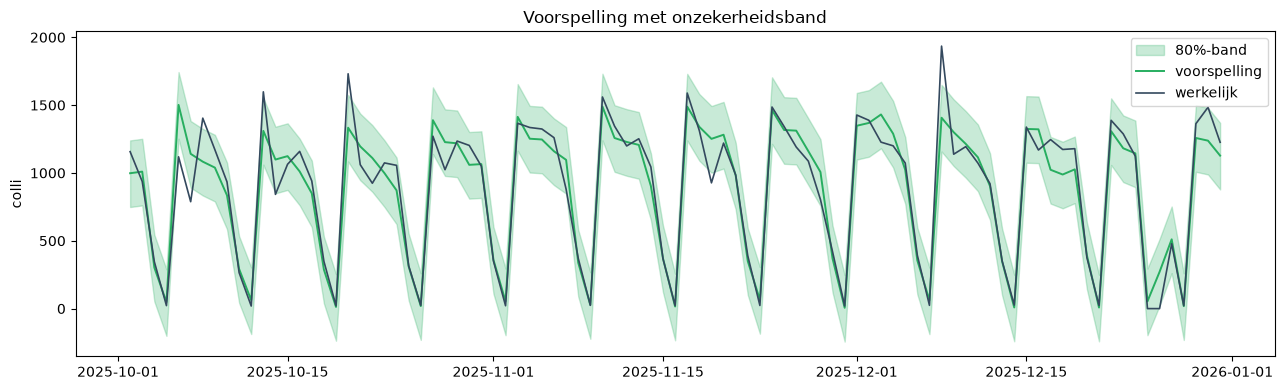

In [55]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(test["datum"], laag, hoog, alpha=.25, color="#27ae60", label="80%-band")
ax.plot(test["datum"], voorsp, color="#27ae60", linewidth=1.4, label="voorspelling")
ax.plot(test["datum"], test["colli"], color="#34495e", linewidth=1.2, label="werkelijk")
ax.set_title("Voorspelling met onzekerheidsband")
ax.set_ylabel("colli")
ax.legend()
plt.tight_layout()
plt.savefig("rapport/f3_band.png", dpi=150)
plt.show()

In [56]:
band = test[["datum", "weekdag", "colli"]].copy()
band["laag"] = laag.round()
band["voorspeld"] = voorsp.round()
band["hoog"] = hoog.round()
band["binnen"] = (test["colli"] >= laag) & (test["colli"] <= hoog)
print(band.iloc[4:11].to_string(index=False))
print()
print(band.groupby("weekdag")["binnen"].mean().round(2))

     datum  weekdag  colli   laag  voorspeld   hoog  binnen
2025-10-06        0   1119 1253.0     1502.0 1744.0   False
2025-10-07        1    788  892.0     1141.0 1383.0   False
2025-10-08        2   1404  834.0     1083.0 1325.0   False
2025-10-09        3   1171  790.0     1039.0 1281.0    True
2025-10-10        4    934  586.0      835.0 1077.0    True
2025-10-11        5    265   43.0      292.0  534.0    True
2025-10-12        6     19 -188.0       62.0  303.0    True

weekdag
0    0.69
1    0.77
2    0.85
3    1.00
4    0.92
5    1.00
6    1.00
Name: binnen, dtype: float64


## How certain is the forecast?

![Forecast with band](rapport/f3_band.png)

**Method (empirical interval):** hold out the last 120 days of training
(calibration), train on the rest, and collect the errors on those 120 days.
The 10th and 90th percentile of the errors form an 80% band:
**-252 to +226 colli** around each forecast.

**Coverage check:** promised 80%, actual **89%** in the test period.
The band is slightly too wide overall.

**But coverage differs per weekday:**

| Weekday | Coverage |
|---|---|
| Monday | **69%** (too narrow) |
| Tue / Wed | 85% |
| Thu / Fri | 92% |
| Sat / Sun | 100% (too wide; Sunday band -185 to 293 for ~20 colli) |

The band has a fixed width (~±240), but uncertainty grows with volume.
The good overall number hides a band that is too narrow on the busiest day.
**Improvement:** a band per weekday or a relative band (in % of the forecast).

Rule: never publish an interval without measuring its coverage.

In [57]:
from sklearn.inspection import permutation_importance

r = permutation_importance(model, test[kenm], test["doel_rel"],
                           n_repeats=10, random_state=42,
                           scoring="neg_mean_absolute_error")

print(pd.DataFrame({"kenmerk": kenm,
                    "belang": r.importances_mean,
                    "spreiding": r.importances_std})
        .sort_values("belang", ascending=False)
        .round(4).to_string(index=False))

        kenmerk  belang  spreiding
        weekdag  0.4781     0.0426
       feestdag  0.0388     0.0077
    dag_vh_jaar  0.0176     0.0048
          rel_7  0.0053     0.0033
         rel_28  0.0047     0.0030
         rel_14  0.0043     0.0020
          maand  0.0026     0.0034
dag_na_feestdag  0.0004     0.0012
feest_7_geleden  0.0000     0.0000
         rel_21 -0.0039     0.0052


## What matters in the model?

Permutation importance on the test set (10 repeats, MAE on the ratio target;
baseline MAE of the ratio is 0.11):

| Feature | Importance | Spread | Verdict |
|---|---|---|---|
| weekdag | 0.477 | 0.043 | dominant: without it the model is useless |
| feestdag | 0.039 | 0.007 | clear: explains the gain in steps 9-10 |
| dag_vh_jaar | 0.019 | 0.004 | clear: seasonality |
| rel_7, rel_14, rel_28 | 0.003-0.007 | ~0.003 | small: weekday and level already cover most |
| maand | 0.003 | 0.004 | noise; overlaps with dag_vh_jaar |
| rel_21 | -0.003 | 0.005 | noise, can be removed |
| dag_na_feestdag | 0.001 | 0.002 | **not measurable**: only 2 cases in test |
| feest_7_geleden | 0.000 | 0.000 | **not measurable**: always 0 in test |

Rule: if the spread is larger than the importance, the feature has no demonstrable effect.

The holiday after-effects are real (step 2: +40% after a holiday), but the
test period has too few cases to measure them. Absence of evidence is not
evidence of absence. Check them on the spring backtest fold instead.

# Forecast of incoming goods — conclusion

**Question:** can we forecast daily incoming volume (colli) one week ahead?

**Answer:** yes. Average error **11.5% per day** and **3.8% per week**,
against 15.0% and 6.5% for the current rule of thumb ("same day last week").

**Where the gain comes from:** mainly holidays. Over Christmas the rule of thumb
was off by ~800 colli per day, the model by ~145. 71% of the total gain comes
from 3 of 91 test days. On normal days the difference is small (11.1% vs 12.1%).

**Reliability:** backtested over five quarters: 14.2% vs 18.6% on average.
The model wins clearly in quarters with holidays (spring: 16.0% vs 29.3%) and
ties in quarters without them. In the first quarter tested (with only one previous
Christmas in the data) it did not yet forecast Christmas correctly: the model
needs at least two years of history to handle holidays.

**Uncertainty:** an 80% band of about -250 to +225 colli around each forecast.
Actual coverage in the test was 89%, but only 69% on Mondays (band too narrow)
and 100% at weekends (band too wide). A band per weekday or in % is the next improvement.

**Key technical choice:** the model predicts the *ratio* to the recent level,
not the number of colli. Tree models cannot extrapolate; without this choice
the model underestimated the busiest days systematically (bias -57 colli per day).

**Recommendation:** use the **weekly** forecast for staff planning.
It is accurate enough (3.8%) and that is the level at which the decision is made.
Around holidays, trust the model over the rule of thumb.

**Limitations:** the test period contains only one holiday period.
Promotions, supplier changes and stock campaigns are not in the data and will
cause deviations this model cannot see. The data is synthetic (training exercise).